In [ ]:


# ──────────────────────────────────────────────────────────────────────────────
# SECTION 0 │ IMPORTS
# ──────────────────────────────────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)



Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:


# ──────────────────────────────────────────────────────────────────────────────
# SECTION 1 │ LOAD DATA  (your original starter code, extended)
# ──────────────────────────────────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

print("=" * 60)
print("  Loading Sign Language MNIST dataset ...")
print("=" * 60)

# Load train split
train_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "datamunge/sign-language-mnist",
    "sign_mnist_train/sign_mnist_train.csv"
)

# Load test split
test_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "datamunge/sign-language-mnist",
    "sign_mnist_test/sign_mnist_test.csv"
)

print(f"\nFirst 5 records:\n{train_df.head()}")
print(f"\nTrain shape : {train_df.shape}")   # (27455, 785)
print(f"Test  shape : {test_df.shape}")      # (7172,  785)
print(f"\nLabel distribution (train):\n{train_df['label'].value_counts().sort_index()}")



Defaulting to user installation because normal site-packages is not writeable
  Loading Sign Language MNIST dataset ...



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



First 5 records:
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206 

In [11]:
train_df.shape

(27455, 785)

In [12]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 2 │ LABEL MAP & PRE-PROCESSING
# ──────────────────────────────────────────────────────────────────────────────
# ASL uses 24 static letters (J=9 and Z=25 need motion → excluded)
LABEL_MAP = {i: chr(65 + i) for i in range(26) if i not in (9, 25)}

def preprocess(df):
    """Split label / pixels, normalise pixels to [0, 1]."""
    y = df["label"].values
    X = df.drop(columns=["label"]).values.astype(np.float32) / 255.0
    return X, y

X_train_flat, y_train = preprocess(train_df)   # shape (27455, 784)
X_test_flat,  y_test  = preprocess(test_df)    # shape (7172,  784)

# Reshape to (N, 28, 28, 1) — required by Conv2D
X_train_img = X_train_flat.reshape(-1, 28, 28, 1)
X_test_img  = X_test_flat.reshape(-1, 28, 28, 1)

# One-hot encode labels for categorical cross-entropy
# Remap labels to continuous integers
unique_labels = sorted(np.unique(y_train))

label_map = {label: idx for idx, label in enumerate(unique_labels)}

y_train_mapped = np.array([label_map[label] for label in y_train])
y_test_mapped  = np.array([label_map[label] for label in y_test])

# One-hot encode labels
num_classes = len(unique_labels)

y_train_cat = to_categorical(y_train_mapped, num_classes)
y_test_cat  = to_categorical(y_test_mapped, num_classes)
print(f"\nClasses     : {num_classes}")
print(f"Train images: {X_train_img.shape}")
print(f"Test  images: {X_test_img.shape}")




Classes     : 24
Train images: (27455, 28, 28, 1)
Test  images: (7172, 28, 28, 1)



[EDA] Generating plots ...


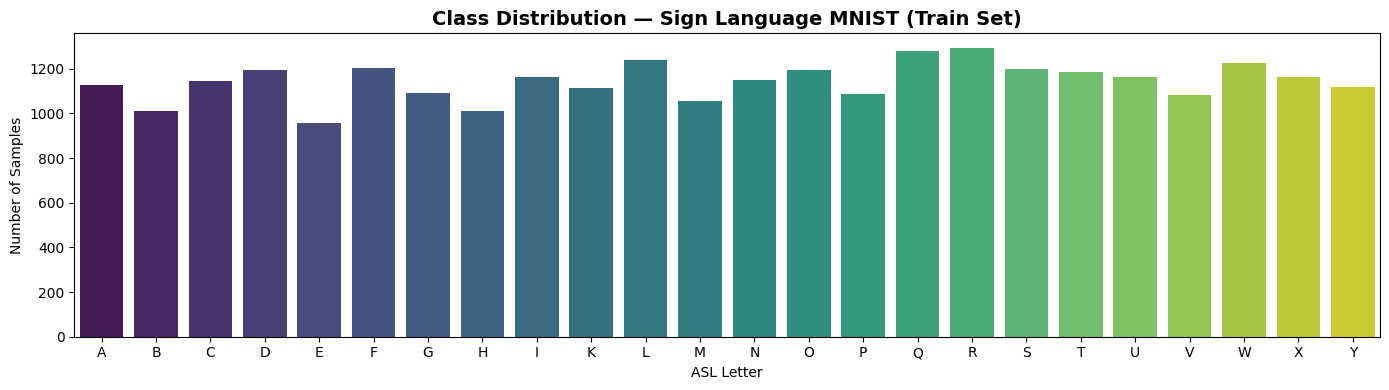

  Saved: eda_class_distribution.png


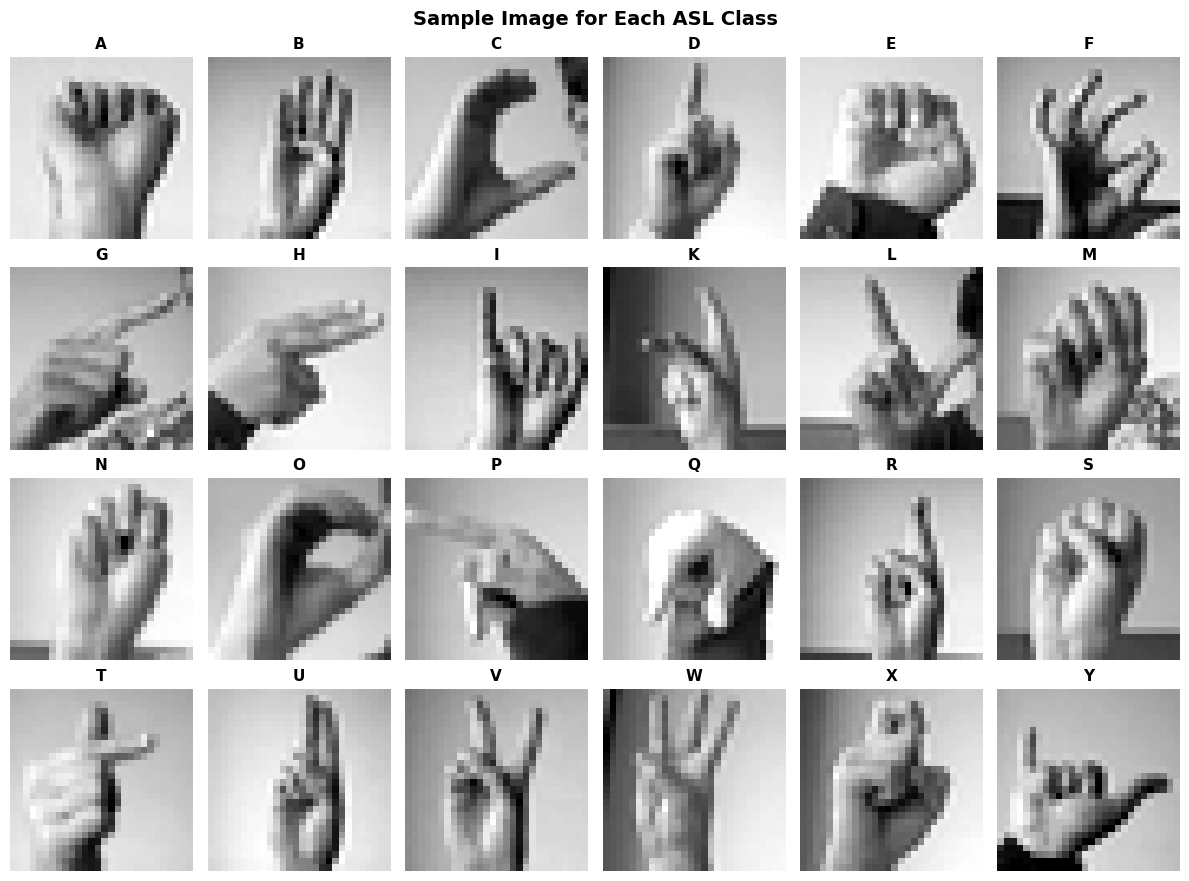

  Saved: eda_sample_images.png


In [13]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 3 │ EXPLORATORY DATA ANALYSIS (EDA)
# ──────────────────────────────────────────────────────────────────────────────
print("\n[EDA] Generating plots ...")

# ── 3a. Class distribution bar chart ──────────────────────────────────────────
labels_sorted  = sorted(train_df["label"].unique())
counts         = [train_df[train_df["label"] == l].shape[0] for l in labels_sorted]
letter_labels  = [LABEL_MAP.get(l, "?") for l in labels_sorted]

plt.figure(figsize=(14, 4))
sns.barplot(x=letter_labels, y=counts, palette="viridis")
plt.title("Class Distribution — Sign Language MNIST (Train Set)",
          fontsize=14, fontweight="bold")
plt.xlabel("ASL Letter")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150)
plt.show()
print("  Saved: eda_class_distribution.png")

# ── 3b. One sample image per class (grid) ─────────────────────────────────────
samples = {}
for img, label in zip(X_train_flat, y_train):
    if label not in samples:
        samples[label] = img
    if len(samples) == num_classes:
        break

fig, axes = plt.subplots(4, 6, figsize=(12, 9))
for ax, (label, img) in zip(axes.flatten(), sorted(samples.items())):
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(LABEL_MAP.get(label, "?"), fontsize=11, fontweight="bold")
    ax.axis("off")

# Hide any unused axes
for ax in axes.flatten()[len(samples):]:
    ax.axis("off")

plt.suptitle("Sample Image for Each ASL Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_sample_images.png", dpi=150)
plt.show()
print("  Saved: eda_sample_images.png")




[MVDA] Running PCA and t-SNE analyses ...


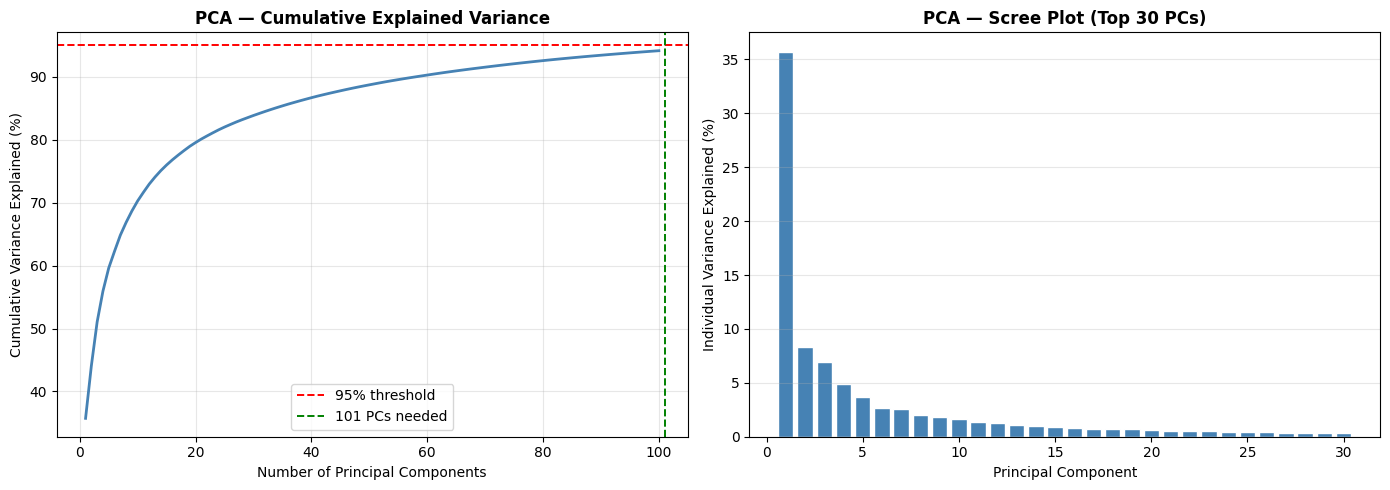

  101 PCs explain 95% of variance  (reduced from 784 features)
  Saved: mvda_pca_variance.png


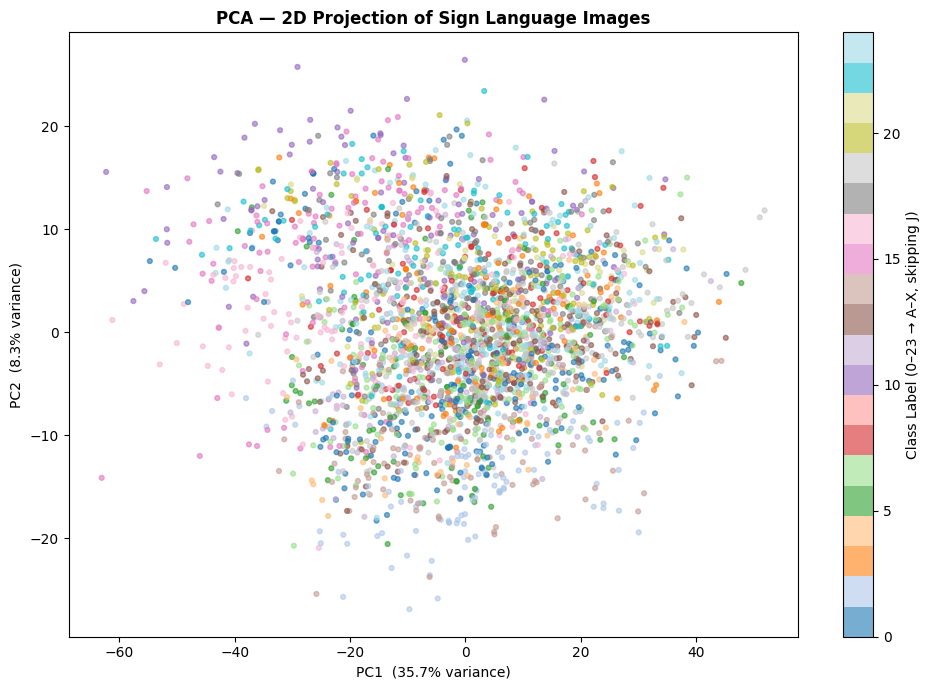

  Saved: mvda_pca_scatter.png


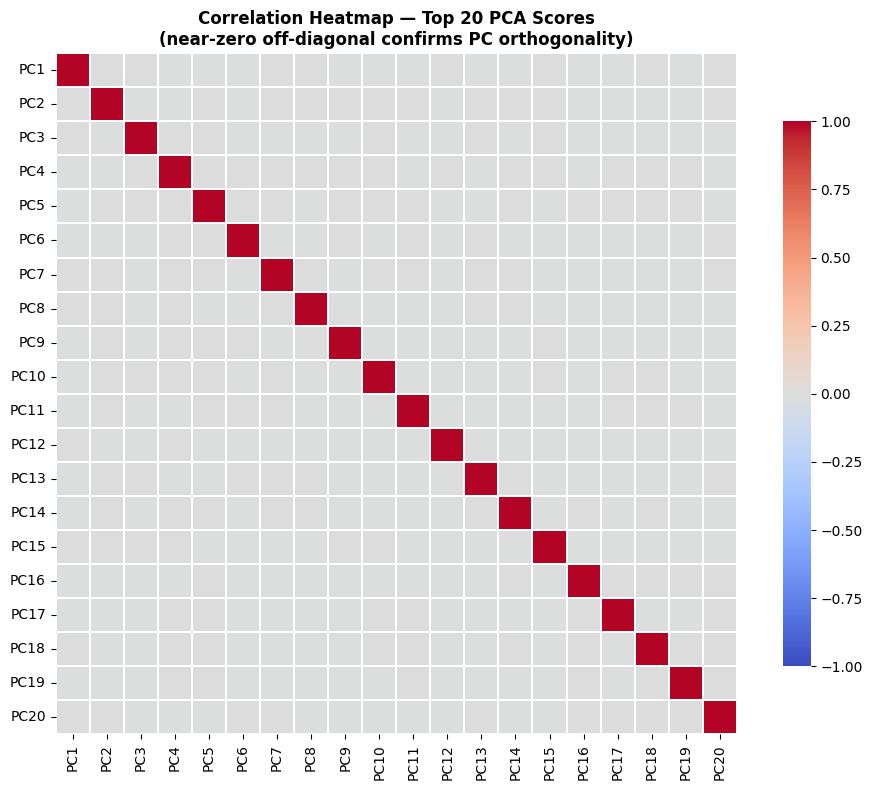

  Saved: mvda_pca_correlation.png
  Running t-SNE (may take ~1 min) ...


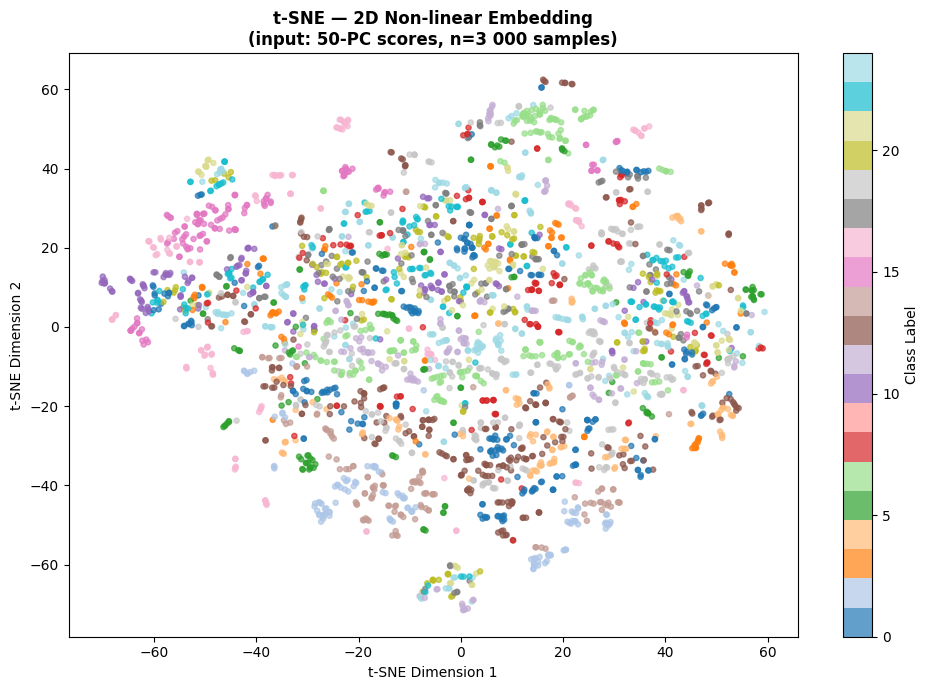

  Saved: mvda_tsne.png


In [24]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 4 │ MULTIVARIATE DATA ANALYSIS (MVDA)
# ──────────────────────────────────────────────────────────────────────────────
print("\n[MVDA] Running PCA and t-SNE analyses ...")

# Standardise pixel vectors (zero mean, unit variance) before PCA
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train_flat)   # (27455, 784)

# ── 4a. PCA — variance explained ──────────────────────────────────────────────
pca_full = PCA(n_components=100, random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95   = int(np.searchsorted(cumvar, 95)) + 1   # PCs needed for 95% variance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance curve
axes[0].plot(range(1, 101), cumvar, color="steelblue", linewidth=2)
axes[0].axhline(95, color="red",   linestyle="--", linewidth=1.4,
                label="95% threshold")
axes[0].axvline(n_95, color="green", linestyle="--", linewidth=1.4,
                label=f"{n_95} PCs needed")
axes[0].set_title("PCA — Cumulative Explained Variance", fontweight="bold")
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Cumulative Variance Explained (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scree plot (top 30)
axes[1].bar(range(1, 31),
            pca_full.explained_variance_ratio_[:30] * 100,
            color="steelblue", edgecolor="white")
axes[1].set_title("PCA — Scree Plot (Top 30 PCs)", fontweight="bold")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Individual Variance Explained (%)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("mvda_pca_variance.png", dpi=150)
plt.show()
print(f"  {n_95} PCs explain 95% of variance  (reduced from 784 features)")
print("  Saved: mvda_pca_variance.png")


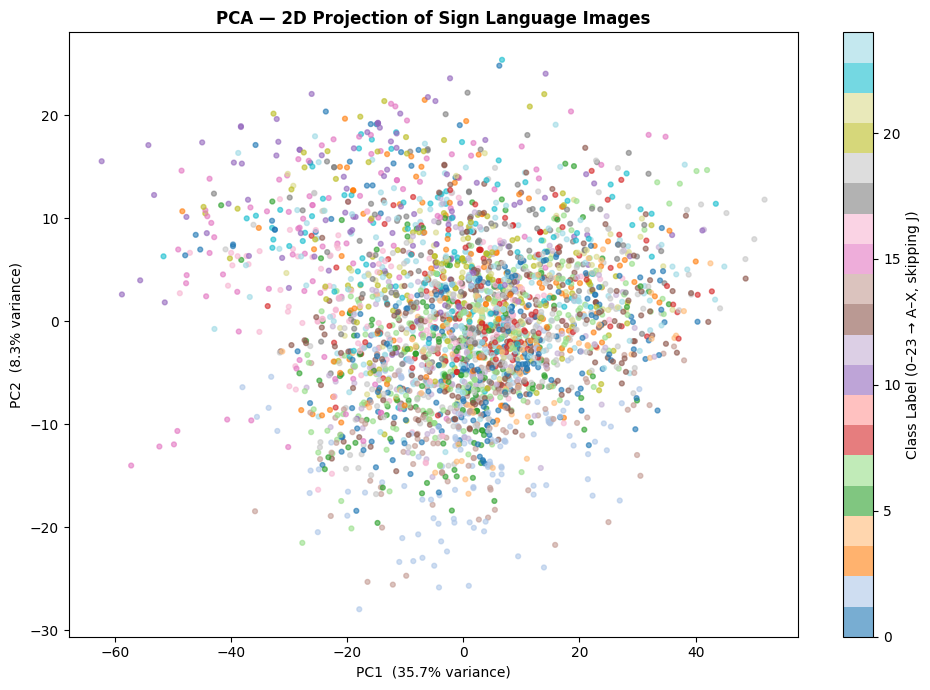

  Saved: mvda_pca_scatter.png


In [29]:

# ── 4b. PCA 2D scatter plot ────────────────────────────────────────────────────
pca2  = PCA(n_components=2, random_state=42)
X_2d  = pca2.fit_transform(X_scaled)

# Sub-sample for readability
idx_plot = np.random.choice(len(X_2d), size=3000, replace=False)

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_2d[idx_plot, 0], X_2d[idx_plot, 1],
                 c=y_train[idx_plot], cmap="tab20",
                 alpha=0.6, s=12)
plt.colorbar(sc, label="Class Label (0–23 → A–X, skipping J)")
plt.title("PCA — 2D Projection of Sign Language Images", fontweight="bold")
plt.xlabel(f"PC1  ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2  ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("mvda_pca_scatter.png", dpi=150)
plt.show()
print("  Saved: mvda_pca_scatter.png")


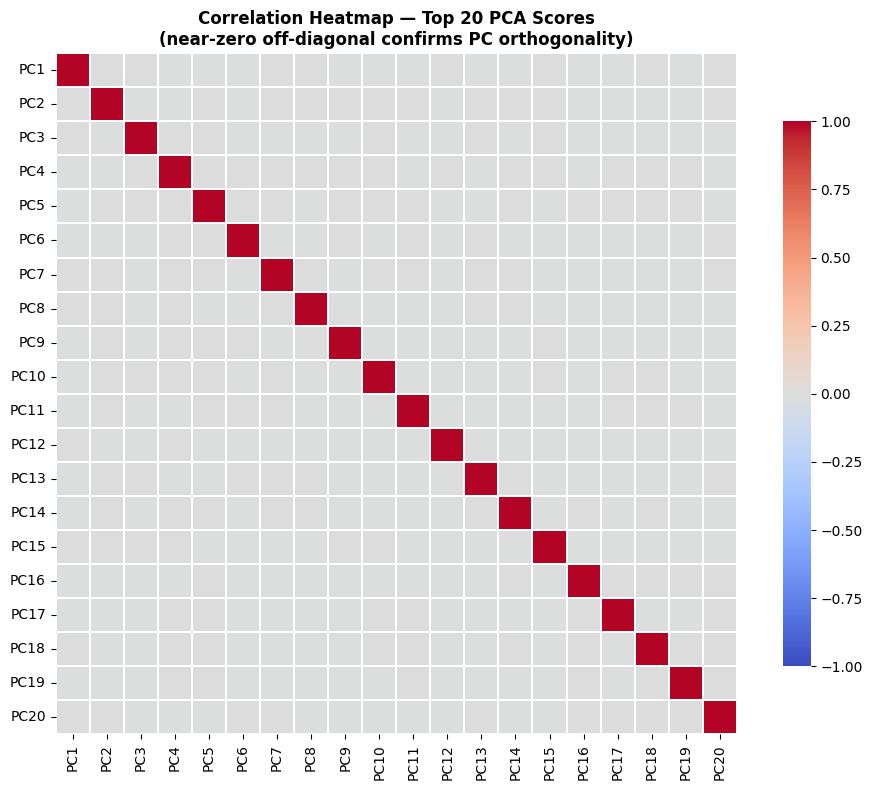

  Saved: mvda_pca_correlation.png
  Running t-SNE (may take ~1 min) ...


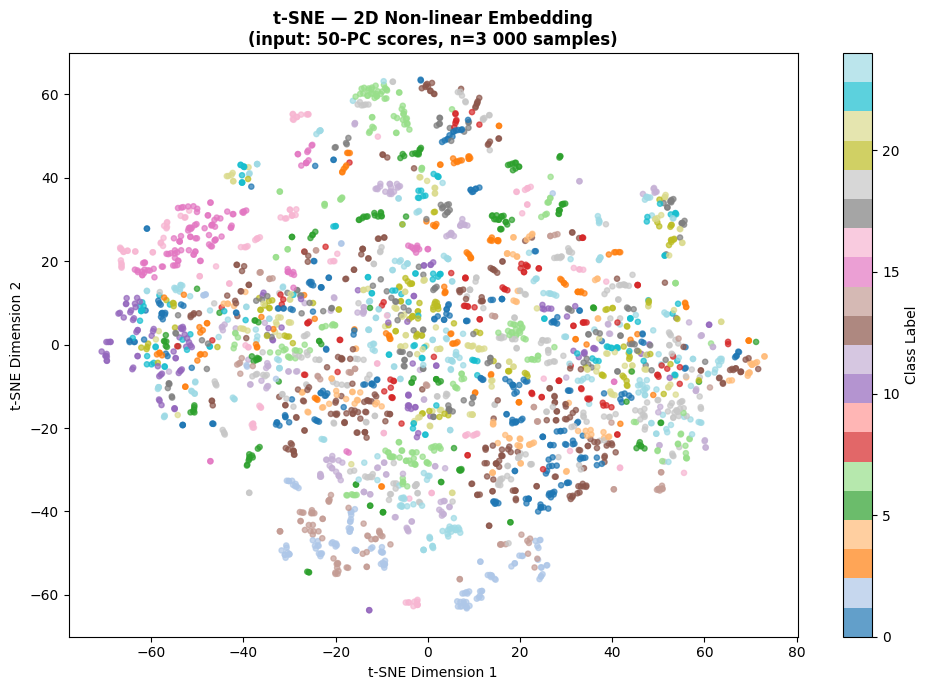

  Saved: mvda_tsne.png


In [28]:

# ── 4c. Correlation heatmap of top-20 PC scores ───────────────────────────────
pca20    = PCA(n_components=20, random_state=42)
X_pca20  = pca20.fit_transform(X_scaled[:5000])
pc_df    = pd.DataFrame(X_pca20, columns=[f"PC{i+1}" for i in range(20)])
corr_mat = pc_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, cmap="coolwarm", center=0,
            square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Top 20 PCA Scores\n"
          "(near-zero off-diagonal confirms PC orthogonality)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("mvda_pca_correlation.png", dpi=150)
plt.show()
print("  Saved: mvda_pca_correlation.png")

# ── 4d. t-SNE — non-linear 2D embedding ───────────────────────────────────────
print("  Running t-SNE (may take ~1 min) ...")

# First compress to 50 PCs for speed, then apply t-SNE
pca50   = PCA(n_components=50, random_state=42)
X_50    = pca50.fit_transform(X_scaled)

idx_tsne = np.random.choice(len(X_50), size=3000, replace=False)
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    random_state=42
)
X_tsne   = tsne.fit_transform(X_50[idx_tsne])

plt.figure(figsize=(10, 7))
sc2 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                  c=y_train[idx_tsne], cmap="tab20",
                  alpha=0.7, s=14)
plt.colorbar(sc2, label="Class Label")
plt.title("t-SNE — 2D Non-linear Embedding\n"
          "(input: 50-PC scores, n=3 000 samples)", fontweight="bold")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.savefig("mvda_tsne.png", dpi=150)
plt.show()
print("  Saved: mvda_tsne.png")



In [15]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 5 │ CNN MODEL DEFINITION
# ──────────────────────────────────────────────────────────────────────────────
def build_cnn(num_classes: int) -> tf.keras.Model:
    """
    3-block CNN:
      Block 1: 2× Conv(32) + BN → MaxPool → Dropout(0.25)
      Block 2: 2× Conv(64) + BN → MaxPool → Dropout(0.25)
      Block 3: 1× Conv(128)+ BN → MaxPool → Dropout(0.25)
      Head   : Dense(256) + BN + Dropout(0.5) → Softmax(num_classes)
    """
    model = Sequential([

        # ── Block 1 ─────────────────────────────────────────────────────────
        Conv2D(32, (3, 3), activation="relu", padding="same",
               input_shape=(28, 28, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Block 2 ─────────────────────────────────────────────────────────
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Block 3 ─────────────────────────────────────────────────────────
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Classification head ──────────────────────────────────────────────
        Flatten(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_cnn(num_classes)
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 442,488 (1.69 MB)

 Trainable params: 441,336 (1.68 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [16]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 6 │ TRAINING
# ──────────────────────────────────────────────────────────────────────────────
callbacks = [
    # Stop training when val_accuracy stops improving for 8 epochs
    EarlyStopping(monitor="val_accuracy", patience=8,
                  restore_best_weights=True, verbose=1),
    # Halve learning rate when val_loss plateaus for 4 epochs
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
]

print("\n[CNN] Training started ...")
history = model.fit(
    X_train_img, y_train_cat,
    validation_split=0.15,      # 15% of train used for validation
    epochs=3,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)
print("[CNN] Training complete.")




[CNN] Training started ...
Epoch 1/3
365/365 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.7136 - loss: 0.9936 - val_accuracy: 0.2187 - val_loss: 2.9750 - learning_rate: 0.0010
Epoch 2/3
365/365 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - accuracy: 0.9737 - loss: 0.0984 - val_accuracy: 1.0000 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 3/3
365/365 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.9920 - loss: 0.0362 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.
[CNN] Training complete.


In [17]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 7 │ EVALUATION
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Evaluation] Running on held-out test set ...")

test_loss, test_acc = model.evaluate(X_test_img, y_test_cat, verbose=0)
print(f"\n  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")

# Predictions
y_pred = np.argmax(model.predict(X_test_img), axis=1)

# Use mapped labels
target_names = [LABEL_MAP[label] for label in unique_labels]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_mapped,
        y_pred,
        target_names=target_names
    )
)




[Evaluation] Running on held-out test set ...

  Test Accuracy : 98.19%
  Test Loss     : 0.0697
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       0.99      1.00      1.00       245
           E       0.97      1.00      0.99       498
           F       1.00      1.00      1.00       247
           G       0.94      0.93      0.93       348
           H       1.00      0.95      0.98       436
           I       1.00      1.00      1.00       288
           K       0.98      0.99      0.98       331
           L       1.00      1.00      1.00       209
           M       0.99      0.97      0.98       394
           N       1.00      0.95      0.97       291
           O       1.00      1.00      1.00       246
           P       1.00 

[Plots] Generating training curves ...


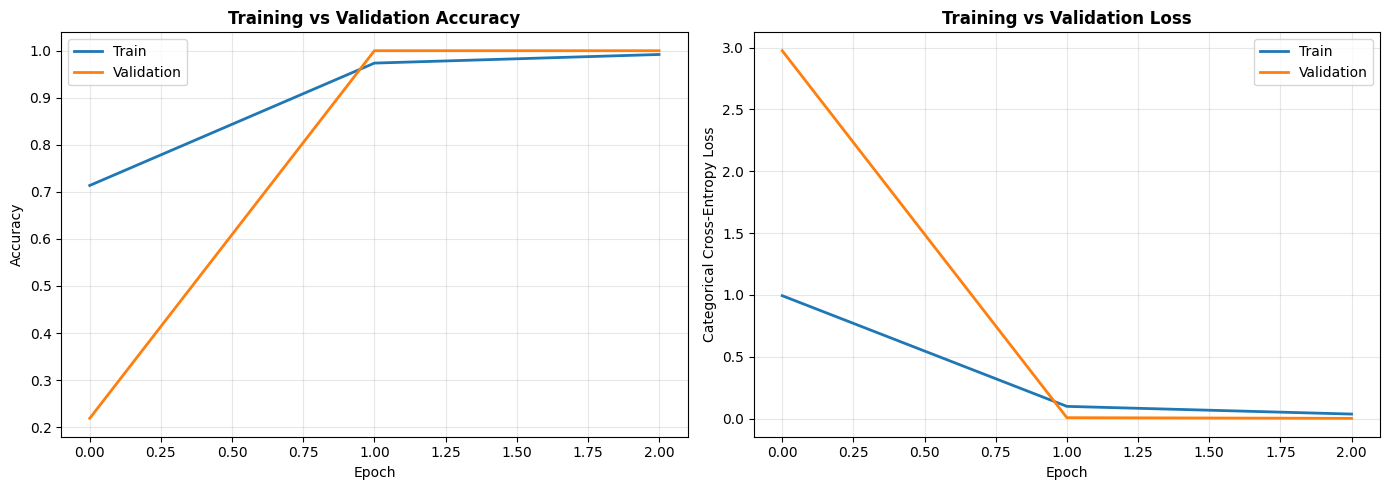

  Saved: cnn_training_curves.png


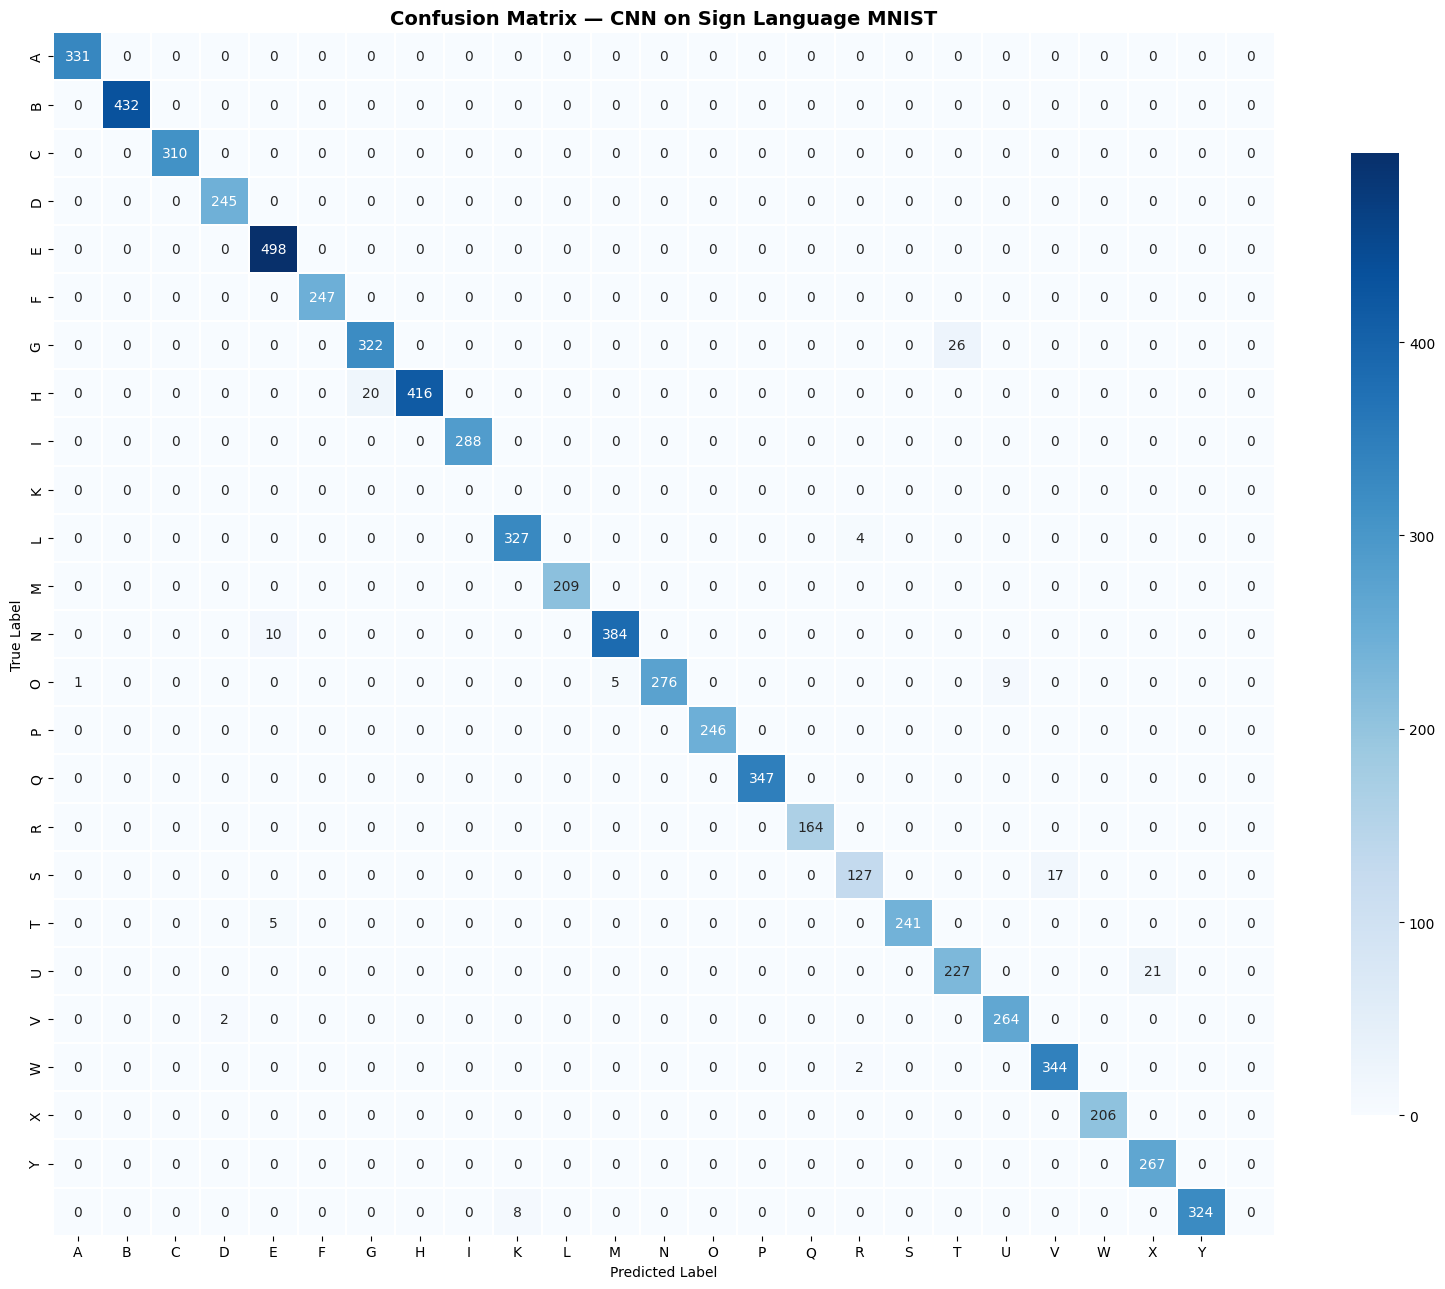

  Saved: cnn_confusion_matrix.png


In [18]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 8 │ VISUALISATIONS — TRAINING CURVES & CONFUSION MATRIX
# ──────────────────────────────────────────────────────────────────────────────
print("[Plots] Generating training curves ...")

# ── 8a. Accuracy & Loss curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train",      linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2)
axes[0].set_title("Training vs Validation Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train",      linewidth=2)
axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2)
axes[1].set_title("Training vs Validation Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Categorical Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()
print("  Saved: cnn_training_curves.png")

# ── 8b. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            linewidths=0.3,
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={"shrink": 0.8})
plt.title("Confusion Matrix — CNN on Sign Language MNIST",
          fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150)
plt.show()
print("  Saved: cnn_confusion_matrix.png")



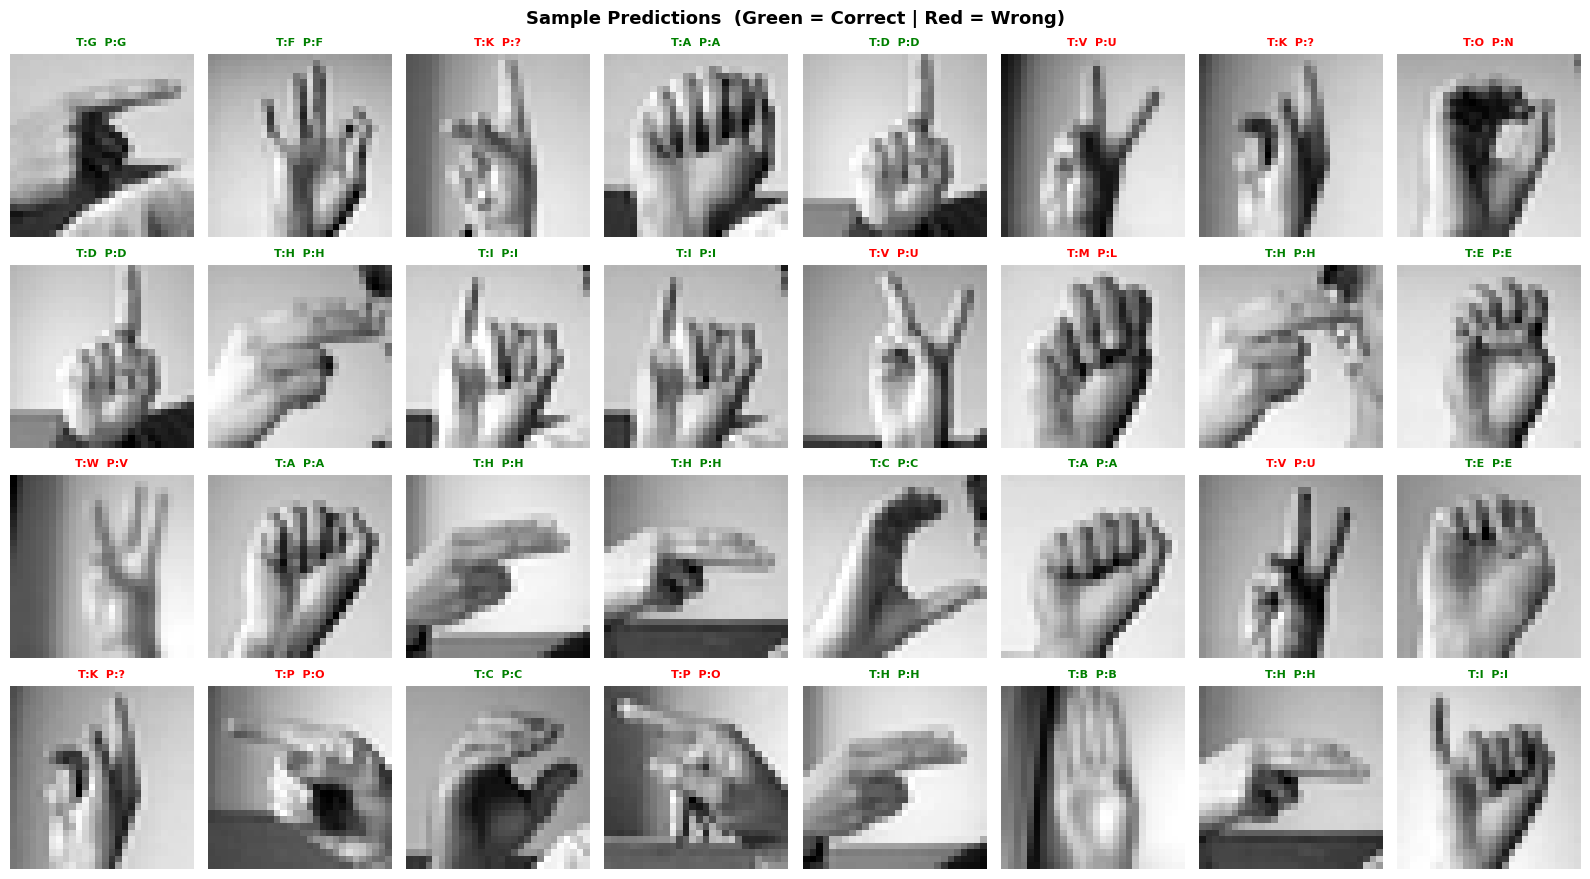

  Saved: cnn_sample_predictions.png


In [19]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 9 │ SAMPLE PREDICTIONS GRID
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 9))

for ax, img, true_lbl, pred_lbl in zip(
        axes.flatten(),
        X_test_flat[:32],
        y_test[:32],
        y_pred[:32]):

    ax.imshow(img.reshape(28, 28), cmap="gray")
    true_letter = LABEL_MAP.get(true_lbl, "?")
    pred_letter = LABEL_MAP.get(pred_lbl, "?")
    colour      = "green" if true_letter == pred_letter else "red"
    ax.set_title(f"T:{true_letter}  P:{pred_letter}",
                 fontsize=8, color=colour, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Predictions  (Green = Correct | Red = Wrong)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_sample_predictions.png", dpi=150)
plt.show()
print("  Saved: cnn_sample_predictions.png")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


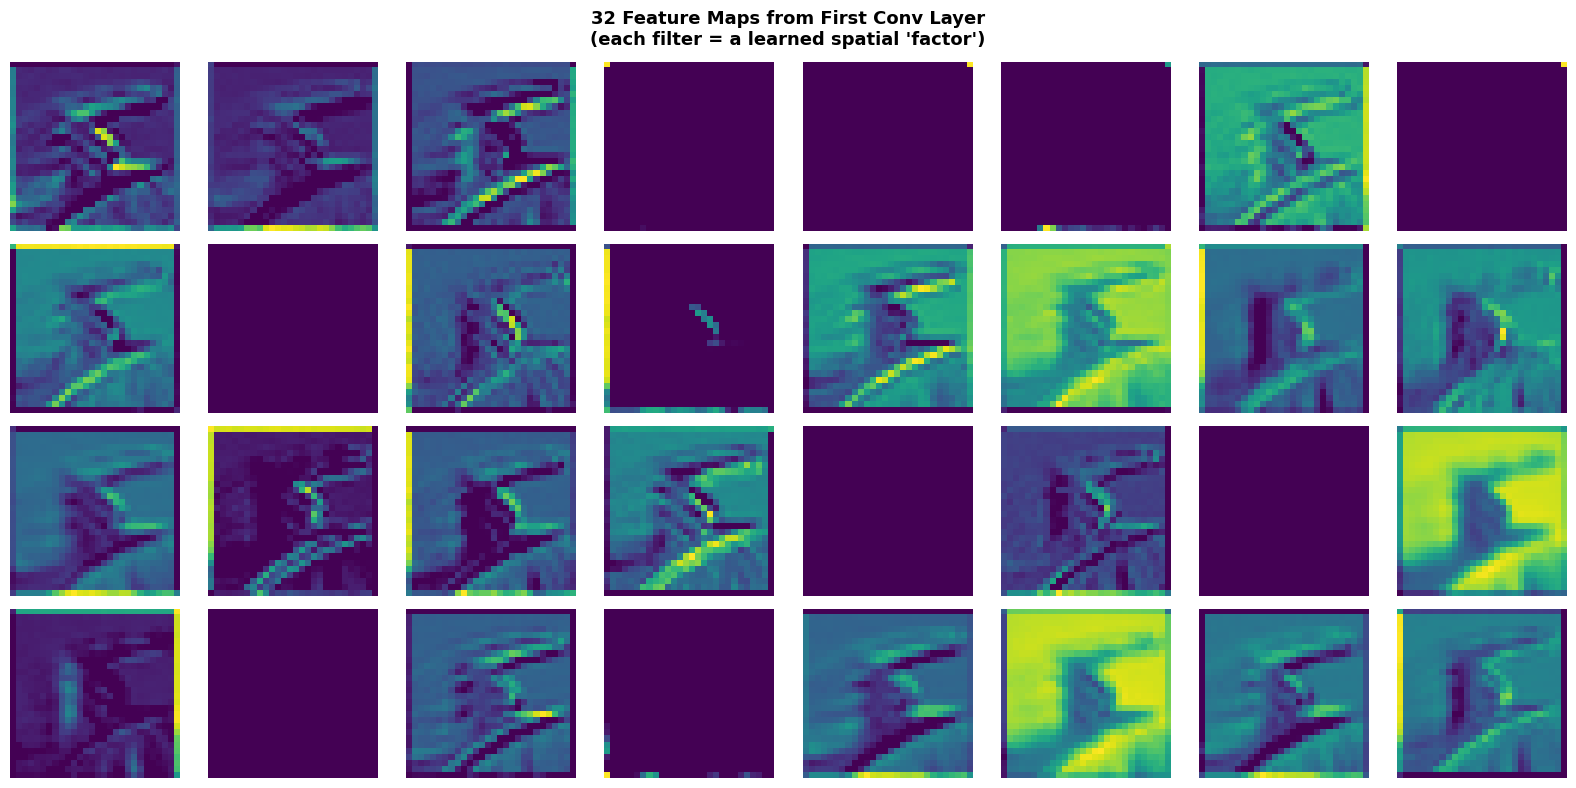

  Saved: cnn_feature_maps.png


In [20]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 10 │ CNN FEATURE MAP VISUALISATION  (MVDA link)
# ──────────────────────────────────────────────────────────────────────────────
# Extract outputs from the very first convolutional layer
# Each feature map is analogous to a "factor loading" in PCA / Factor Analysis
feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)
fmaps = feature_extractor.predict(X_test_img[:1])   # (1, 28, 28, 32)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < fmaps.shape[-1]:
        ax.imshow(fmaps[0, :, :, i], cmap="viridis")
    ax.axis("off")

plt.suptitle("32 Feature Maps from First Conv Layer\n"
             "(each filter = a learned spatial 'factor')",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_feature_maps.png", dpi=150)
plt.show()
print("  Saved: cnn_feature_maps.png")



In [21]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 11 │ FINAL SUMMARY
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset          : Sign Language MNIST")
print(f"  Train samples    : {X_train_img.shape[0]}")
print(f"  Test  samples    : {X_test_img.shape[0]}")
print(f"  Raw features     : 784 pixels / image")
print(f"  PCA 95% variance : {n_95} components")
print(f"  CNN Architecture : 3-Block Conv (32→64→128) + Dense(256)")
print(f"  Test Accuracy    : {test_acc * 100:.2f}%")
print(f"  Test Loss        : {test_loss:.4f}")
print("=" * 60)
print("\n  Output files generated:")
files = [
    "eda_class_distribution.png",
    "eda_sample_images.png",
    "mvda_pca_variance.png",
    "mvda_pca_scatter.png",
    "mvda_pca_correlation.png",
    "mvda_tsne.png",
    "cnn_training_curves.png",
    "cnn_confusion_matrix.png",
    "cnn_sample_predictions.png",
    "cnn_feature_maps.png",
]
for f in files:
    print(f"    ✓ {f}")


  FINAL RESULTS SUMMARY
  Dataset          : Sign Language MNIST
  Train samples    : 27455
  Test  samples    : 7172
  Raw features     : 784 pixels / image
  PCA 95% variance : 101 components
  CNN Architecture : 3-Block Conv (32→64→128) + Dense(256)
  Test Accuracy    : 98.19%
  Test Loss        : 0.0697

  Output files generated:
    ✓ eda_class_distribution.png
    ✓ eda_sample_images.png
    ✓ mvda_pca_variance.png
    ✓ mvda_pca_scatter.png
    ✓ mvda_pca_correlation.png
    ✓ mvda_tsne.png
    ✓ cnn_training_curves.png
    ✓ cnn_confusion_matrix.png
    ✓ cnn_sample_predictions.png
    ✓ cnn_feature_maps.png
